In [9]:
import gzip
import os
import re
from datetime import datetime
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
# --- Config ---
log_dir = "/Users/shubham.panday/Desktop/test"  # Your .log.gz folder
keywords = ["error", "timeout", "failed","301"]  # 🔍 List of keywords to track
timestamp_format = "%Y-%m-%dT%H:%M:%S"  # Adjust to match your log format
time_bucket = "minute"  # "minute", "hour"

In [6]:
# --- Helpers ---
def round_time(ts, unit="minute"):
    if unit == "minute":
        return ts.replace(second=0, microsecond=0)
    elif unit == "hour":
        return ts.replace(minute=0, second=0, microsecond=0)
    return ts


In [7]:
# --- Compile Patterns ---
keyword_patterns = {kw: re.compile(kw, re.IGNORECASE) for kw in keywords}
timestamp_pattern = re.compile(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}")  # Adjust if needed

In [10]:
# --- Data Aggregation ---
error_counts = defaultdict(Counter)  # {keyword: Counter({timestamp: count})}

for filename in os.listdir(log_dir):
    if filename.endswith(".log.gz"):
        with gzip.open(os.path.join(log_dir, filename), 'rt', encoding='utf-8', errors='ignore') as file:
            for line in file:
                ts_match = timestamp_pattern.search(line)
                if ts_match:
                    try:
                        ts = datetime.strptime(ts_match.group(), timestamp_format)
                        ts_bucket = round_time(ts, time_bucket)
                        for kw, pattern in keyword_patterns.items():
                            if pattern.search(line):
                                error_counts[kw][ts_bucket] += 1
                    except Exception:
                        continue

In [ ]:
# Show the first 10 error lines
for i, (fname, line) in enumerate(error_lines[:10]):
    print(f"[{fname}] {line}")

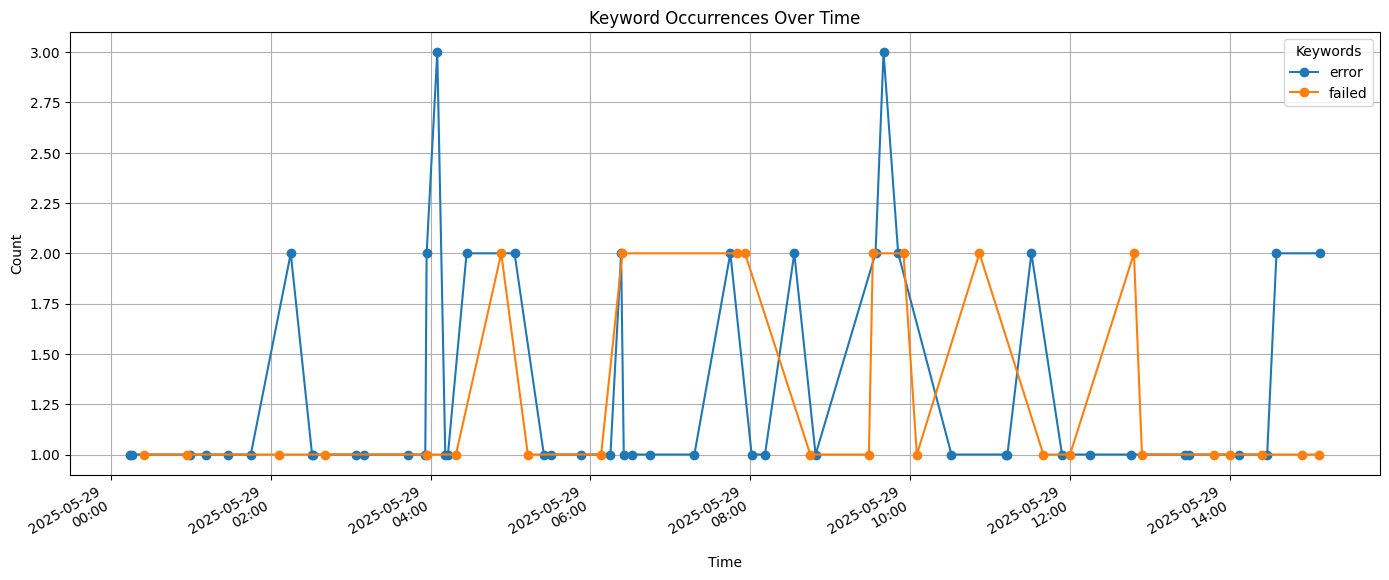

In [11]:
# --- Plotting ---
plt.figure(figsize=(14, 6))
has_data = False

for kw, counts in error_counts.items():
    if counts:
        times, values = zip(*sorted(counts.items()))
        plt.plot(times, values, marker='o', linestyle='-', label=kw)
        has_data = True

if has_data:
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
    plt.title("Keyword Occurrences Over Time")
    plt.xlabel("Time")
    plt.ylabel("Count")
    plt.legend(title="Keywords")
    plt.grid(True)
    plt.tight_layout()
    plt.gcf().autofmt_xdate()
    plt.show()
else:
    print("No matches found for any of the keywords.")